In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

vectorizer = TfidfVectorizer()

#Labelling the columns of the dataframe and sorting verses into the correct order

df = pd.read_csv('../data/quran.csv')
cols = list(df.columns)
cols[0] = 'chapter#' 
cols[1] = 'verse#'
cols[2] = 'd_verse'
cols[3] = 'verse'
cols[9] = 'd_chapter'
cols[10] = 'chapter'
df.columns = cols

df = df.sort_values(by=['chapter#','verse#']).reset_index(drop=True)
df.drop([6459], axis=0, inplace=True)


In [11]:
for idx, x in df['verse'].items():
    if pd.isna(x): print(idx)

In [4]:
df[pd.isna(df.verse)]
df.tail()

,chapter#,verse#,d_verse,verse,22b81fd12c136d4cf67a37de941908d83eaf8e97571c4983f9308d30d52ad8f9,0.25,1.1,١,1.2,d_chapter,chapter,1.3,0.1
6454,114,2,مَلِكِ ٱلنَّاسِ,ملك الناس,ee43221a2d70da314a28481e2858b355b84ea76cc5505a...,60.0,604,٦٠٤,6456,سُورَةُ النَّاسِ,سورة الناس,30,0
6455,114,3,إِلَٰهِ ٱلنَّاسِ,الٰه الناس,83ea524a3332531b96d8b06c387410ac2371c0e79d7960...,60.0,604,٦٠٤,6457,سُورَةُ النَّاسِ,سورة الناس,30,0
6456,114,4,مِن شَرِّ ٱلۡوَسۡوَاسِ ٱلۡخَنَّاسِ,من شر الوسواس الخناس,04af28c8924483450a6968f46189467994eccf451daa8a...,60.0,604,٦٠٤,6458,سُورَةُ النَّاسِ,سورة الناس,30,0
6457,114,5,ٱلَّذِي يُوَسۡوِسُ فِي صُدُورِ ٱلنَّاسِ,الذي يوسوس في صدور الناس,6d5da11704c8c0a3fce24b7038f963c0ff6922063d7673...,60.0,604,٦٠٤,6459,سُورَةُ النَّاسِ,سورة الناس,30,0
6458,114,6,مِنَ ٱلۡجِنَّةِ وَٱلنَّاسِ,من الجنة والناس,3020b3a83101b27789ad8db9a84b00a9c97271013bf79e...,60.0,604,٦٠٤,6460,سُورَةُ النَّاسِ,سورة الناس,30,0


In [ ]:
# Run K means and create "Cluster" column in dataframe to store cluster numbers for each verse
vectorized_ayaah = vectorizer.fit_transform(df['verse'])

kmeans = KMeans(n_clusters=70, random_state=42)
df['cluster'] = kmeans.fit_predict(vectorized_ayaah)
print(df)

      chapter#  verse#                                   d_verse  \
0            1       1    بِسۡمِ ٱللَّهِ ٱلرَّحۡمَٰنِ ٱلرَّحِيمِ   
1            1       2     ٱلۡحَمۡدُ لِلَّهِ رَبِّ ٱلۡعَٰلَمِينَ   
2            1       3                   ٱلرَّحۡمَٰنِ ٱلرَّحِيمِ   
3            1       4                   مَٰلِكِ يَوۡمِ ٱلدِّينِ   
4            1       5  إِيَّاكَ نَعۡبُدُ وَإِيَّاكَ نَسۡتَعِينُ   
...        ...     ...                                       ...   
6454       114       2                           مَلِكِ ٱلنَّاسِ   
6455       114       3                          إِلَٰهِ ٱلنَّاسِ   
6456       114       4        مِن شَرِّ ٱلۡوَسۡوَاسِ ٱلۡخَنَّاسِ   
6457       114       5   ٱلَّذِي يُوَسۡوِسُ فِي صُدُورِ ٱلنَّاسِ   
6458       114       6                مِنَ ٱلۡجِنَّةِ وَٱلنَّاسِ   

                         verse  \
0      بسم الله الرحمٰن الرحيم   
1        الحمد لله رب العٰلمين   
2               الرحمٰن الرحيم   
3               مٰلك يوم الدين   
4       اياك 

In [ ]:
# Running K means again with normalized verse vectors
from sklearn.preprocessing import normalize

vectorized_ayaah_norm = normalize(vectorized_ayaah)

kmeans = KMeans(n_clusters=70, random_state=42)
df['cluster'] = kmeans.fit_predict(vectorized_ayaah_norm)

In [8]:
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)  # Don't wrap to fit width
pd.set_option('display.max_colwidth', None)  # Show full column content

df.head(5)

,chapter#,verse#,d_verse,verse,22b81fd12c136d4cf67a37de941908d83eaf8e97571c4983f9308d30d52ad8f9,0.25,1.1,١,1.2,d_chapter,chapter,1.3,0.1,cluster
0,1,1,بِسۡمِ ٱللَّهِ ٱلرَّحۡمَٰنِ ٱلرَّحِيمِ,بسم الله الرحمٰن الرحيم,803dee27b5a9ddf866112eac2f8a34e5bd83ca08015ec4acaaffeba25a378352,0.25,1,١,2,سُورَةُ الفَاتِحَةِ,سورة الفاتحة,1,0,10
1,1,2,ٱلۡحَمۡدُ لِلَّهِ رَبِّ ٱلۡعَٰلَمِينَ,الحمد لله رب العٰلمين,ef2e84a7a99f9340845888a735cf6950853f9e1a13cff30f4c1e7648e56ee51b,0.25,1,١,3,سُورَةُ الفَاتِحَةِ,سورة الفاتحة,1,0,16
2,1,3,ٱلرَّحۡمَٰنِ ٱلرَّحِيمِ,الرحمٰن الرحيم,fa43107ca02d890e5115053aed9835bfbefb79ffa6846491cf7dfc67c8fd8be7,0.25,1,١,4,سُورَةُ الفَاتِحَةِ,سورة الفاتحة,1,0,10
3,1,4,مَٰلِكِ يَوۡمِ ٱلدِّينِ,مٰلك يوم الدين,4355fb3e57b0b8b4e47545d28d30b98359fea1a18e5bfc3dc948eeab653901e5,0.25,1,١,5,سُورَةُ الفَاتِحَةِ,سورة الفاتحة,1,0,56
4,1,5,إِيَّاكَ نَعۡبُدُ وَإِيَّاكَ نَسۡتَعِينُ,اياك نعبد واياك نستعين,8fc4ad4ff4e86be9abf8b5c66fd47a316b760844456c87ec85806ac3473471e9,0.25,1,١,6,سُورَةُ الفَاتِحَةِ,سورة الفاتحة,1,0,0


In [ ]:
# Store K means clustered verse dataframe as csv
df.loc[:, ['chapter#', 'verse#', 'verse', 'chapter', 'cluster'] ].to_csv('../data/clustered_verses.csv', index=False, encoding='utf-8-sig')

In [7]:
def elbow_method(data, k_range):
    k_axis = []
    inertias =[]
    for k in range(1, k_range):
        print(f"Testing k={k}...")
        kmeans = KMeans(n_clusters=k)
        kmeans.fit(data)
        k_axis.append(k)
        inertias.append(kmeans.inertia_)
    
    fig = plt.subplots(figsize=(10,5))
    plt.plot(k_axis, inertias, 'o-')
    plt.xlabel("Number of clusters")
    plt.ylabel("Inertia")
    plt.grid(True)
    plt.show()

Testing k=1...
Testing k=2...
Testing k=3...
Testing k=4...
Testing k=5...
Testing k=6...
Testing k=7...
Testing k=8...
Testing k=9...
Testing k=10...
Testing k=11...
Testing k=12...
Testing k=13...
Testing k=14...
Testing k=15...
Testing k=16...
Testing k=17...
Testing k=18...
Testing k=19...
Testing k=20...
Testing k=21...
Testing k=22...
Testing k=23...
Testing k=24...
Testing k=25...
Testing k=26...
Testing k=27...
Testing k=28...
Testing k=29...
Testing k=30...
Testing k=31...
Testing k=32...
Testing k=33...
Testing k=34...
Testing k=35...
Testing k=36...
Testing k=37...
Testing k=38...
Testing k=39...
Testing k=40...
Testing k=41...
Testing k=42...
Testing k=43...
Testing k=44...
Testing k=45...
Testing k=46...
Testing k=47...
Testing k=48...
Testing k=49...
Testing k=50...
Testing k=51...
Testing k=52...
Testing k=53...
Testing k=54...
Testing k=55...
Testing k=56...
Testing k=57...
Testing k=58...
Testing k=59...
Testing k=60...
Testing k=61...
Testing k=62...
Testing k=63...
T

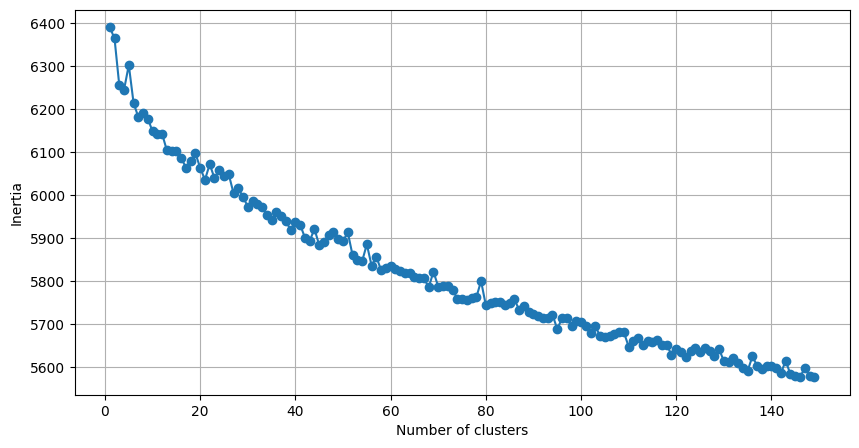

In [8]:
elbow_method(vectorized_ayaah, 150)